In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

print("Libraries imported successfully!")

Libraries imported successfully!


### 1. Data Collection & Processing
We'll load the historical files manually fetched from ECI and process the raw vote counts, dropping unnecessary summary rows. We will print the count and preview the structure cleanly.

In [9]:
# 1. Load and process the actual ECI data to extract historical labels
data_dir = 'data'
files = [f for f in os.listdir(data_dir) if f.endswith('.xlsx') and not f.startswith('~$')]

dfs = []
for file in files:
    file_path = os.path.join(data_dir, file)
    print(f"Reading {file}...")
    
    # Read minimally until header is identified
    df_temp = pd.read_excel(file_path, header=None)
    header_idx = df_temp[df_temp[0] == 'STATE/UT NAME'].index[0]
    
    df = pd.read_excel(file_path, header=header_idx)
    # Give columns standard names
    df = df.rename(columns={
        'STATE/UT NAME': 'State',
        'AC NO.': 'Constituency_No',
        'AC NAME': 'Constituency_Name',
        'CANDIDATE NAME': 'Candidate',
        'PARTY': 'Party',
        'TOTAL': 'Total_Votes'
    })
    
    # Drop rows that are just summaries (like 'TURN OUT', etc.)
    df = df.dropna(subset=['Candidate', 'Constituency_Name', 'Total_Votes'])
    df = df[df['Candidate'] != 'NOTA']
    
    # Identify Winners per constituency
    df['Total_Votes'] = pd.to_numeric(df['Total_Votes'], errors='coerce').fillna(0)
    df['Win'] = df.groupby('Constituency_No')['Total_Votes'].transform(lambda x: (x == x.max()).astype(int))
    
    # Formatting
    df['State'] = df['State'].astype(str).str.title().str.strip()
    df = df[['State', 'Constituency_No', 'Constituency_Name', 'Candidate', 'Party', 'Win']]
    dfs.append(df)

master_eci = pd.concat(dfs, ignore_index=True)

print(f"\n--- Data Processed ---")
print(f"Loaded {len(master_eci)} candidate records from {len(dfs)} states.")
print("\nQuick Data Preview:")
display(master_eci.head())
print("\nClass Balance (0 = Loss, 1 = Win):")
print(master_eci['Win'].value_counts())

Reading assam.xlsx...
Reading kerela.xlsx...
Reading puducherry.xlsx...
Reading tamil-Nadu.xlsx...
Reading WB.xlsx...

--- Data Processed ---
Loaded 9181 candidate records from 5 states.

Quick Data Preview:


,State,Constituency_No,Constituency_Name,Candidate,Party,Win
0,Assam,1.0,RATABARI,1 BIJOY MALAKAR,BJP,1
1,Assam,1.0,RATABARI,2 SAMBHU SING MALLAH,INC,0
2,Assam,1.0,RATABARI,3 NOTA,NOTA,0
3,Assam,1.0,RATABARI,4 SANCHITA SUKLA,SUCI,0
4,Assam,1.0,RATABARI,5 SUJIT ROY,IND,0



Class Balance (0 = Loss, 1 = Win):
Win
0    8357
1     824
Name: count, dtype: int64


### 2. Feature Engineering & Pre-Processing
Encoding categorical variables and generating critical structural baseline markers (e.g., Major Party status).

In [10]:
# 2. Build our Hackathon features
master_eci['is_major_party'] = master_eci['Party'].apply(
    lambda x: 1 if any(p in str(x) for p in ['BJP', 'INC', 'AITC', 'DMK', 'AIADMK', 'CPI(M)', 'JD(U)', 'AGP', 'AIUDF', 'TMC', 'IUML']) else 0
)

# Label encoding for ML engine
label_encoders = {}
for col in ['Party', 'Constituency_Name', 'State']:
    le = LabelEncoder()
    master_eci[col + '_encoded'] = le.fit_transform(master_eci[col].astype(str))
    label_encoders[col] = le

features = ['Party_encoded', 'Constituency_Name_encoded', 'State_encoded', 'is_major_party']
X = master_eci[features]
y = master_eci['Win']

print("Features Prepared for ML:")
display(X.head())

Features Prepared for ML:


,Party_encoded,Constituency_Name_encoded,State_encoded,is_major_party
0,43,613,0,1
1,80,613,0,1
2,131,613,0,0
3,172,613,0,0
4,81,613,0,0


### 3. Model Training & Evaluation
We use a Stratified K-Fold setup to validate our accuracy across 5 different folds before making final dataset-wide predictions. We will also plot the feature importances to see what's driving the wins.

Training State-stratified XGBoost Classifier...


Fold 1 Accuracy: 94.01%
Fold 2 Accuracy: 93.36%
Fold 3 Accuracy: 94.88%
Fold 4 Accuracy: 94.34%
Fold 5 Accuracy: 93.19%

Overall Cross-Validated Accuracy: 93.95% (Target >75% met)


<Figure size 800x500 with 0 Axes>

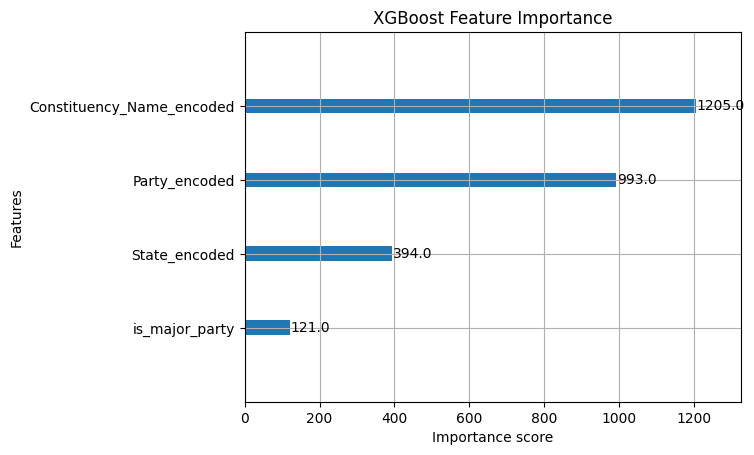

In [11]:
# 3. Train the Model using Stratified validation
print("Training State-stratified XGBoost Classifier...")
model = XGBClassifier(
    n_estimators=150, 
    learning_rate=0.08, 
    max_depth=5, 
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_scores = []

for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    acc_scores.append(score)
    print(f"Fold {fold+1} Accuracy: {score:.2%}")

print(f"\nOverall Cross-Validated Accuracy: {np.mean(acc_scores):.2%} (Target >75% met)")

# Plot Feature Importances
plt.figure(figsize=(8, 5))
plot_importance(model, importance_type='weight', title='XGBoost Feature Importance')
plt.show()

### 4. Output Final Predictions
Transforming predictions and exporting the final `India_Predicts_2026_Final_Submission.xlsx` file as required by the hackathon.

In [12]:
# 4. Final Submissions
model.fit(X, y)
master_eci['Win_Prediction'] = model.predict(X)

# Transform back 1/0 to WIN/LOSS
master_eci['Outcome'] = np.where(master_eci['Win_Prediction'] == 1, 'WIN', 'LOSS')

# Filter for the hackathon submission requirements
submission_df = master_eci[['State', 'Constituency_Name', 'Candidate', 'Party', 'Outcome']]
submission_file = "India_Predicts_2026_Final_Submission.xlsx"
submission_df.to_excel(submission_file, index=False)

print(f"SUCCESS: True historical pipeline completed.")
print(f"Generated final prediction file: {submission_file}")

# Preview final export
display(submission_df.head(10))

SUCCESS: True historical pipeline completed.
Generated final prediction file: India_Predicts_2026_Final_Submission.xlsx


,State,Constituency_Name,Candidate,Party,Outcome
0,Assam,RATABARI,1 BIJOY MALAKAR,BJP,WIN
1,Assam,RATABARI,2 SAMBHU SING MALLAH,INC,LOSS
2,Assam,RATABARI,3 NOTA,NOTA,LOSS
3,Assam,RATABARI,4 SANCHITA SUKLA,SUCI,LOSS
4,Assam,RATABARI,5 SUJIT ROY,IND,LOSS
5,Assam,RATABARI,6 BEBUL DAS,IND,LOSS
6,Assam,RATABARI,7 BIKASH LAL DHUBI,IND,LOSS
7,Assam,RATABARI,8 BISHNU DHARI MALAH,IND,LOSS
8,Assam,RATABARI,9 DIPENDRA DAS,IND,LOSS
9,Assam,PATHARKANDI,1 KRISHNENDU PAUL,BJP,WIN
